In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# Load Dataset

df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/master/Data%20Sets/penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [56]:
# Let us strictly remove missing data

df = df.dropna()
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [57]:
# Label Encoding (for Categorical features)

# Assigns X
X = pd.get_dummies(df.drop('species', axis = 1), drop_first = True)
X

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,True,False,True
...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,True,False
340,46.8,14.3,215.0,4850.0,False,False,True,False
341,50.4,15.7,222.0,5750.0,False,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,True,False


In [58]:
# Assign y
y = df['species']

In [59]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 101)

In [60]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

In [61]:
# Model Hyperparameters

model = RandomForestClassifier(n_estimators = 10, random_state = 101)

In [62]:
# Model Fitting

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=101)

In [63]:
# Predictions

predictions = model.predict(X_test)
predictions

array(['Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Chinstrap', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'A

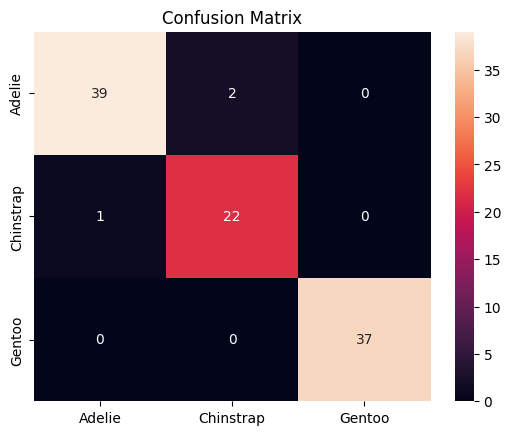

In [64]:
# Confusion Matrix & Classification Report

from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot = True, fmt = 'g', xticklabels = ['Adelie', 'Chinstrap', 'Gentoo'], yticklabels = ['Adelie', 'Chinstrap', 'Gentoo']).set(title = 'Confusion Matrix')
plt.show()

In [65]:
# Classification Report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96        41
   Chinstrap       0.92      0.96      0.94        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.96      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101



In [66]:
# Grid Search Import (Hyperparameter Optimization)

from sklearn.model_selection import GridSearchCV

In [67]:
# Configuration Lists

n_estimators = [10, 20, 30, 40, 50, 60] # Ilang Decision Tree ang kailangan for Prediction (optimized)
max_features = [1,2,3,4,5,6,7,8]

In [68]:
# Parameter Grids

param_grid = {'n_estimators': n_estimators, 'max_features': max_features}

In [69]:
# GridSearch Proper

model = RandomForestClassifier(random_state = 101)
grid = GridSearchCV(model, param_grid)

In [70]:
# GridSearch Fitting

grid.fit(X_train, y_train) # Eto ay fi-nit ang optimized configuration for RF via Grid Search

GridSearchCV(estimator=RandomForestClassifier(random_state=101),
             param_grid={'max_features': [1, 2, 3, 4, 5, 6, 7, 8],
                         'n_estimators': [10, 20, 30, 40, 50, 60]})

In [71]:
# Identify Best Parameters

grid.best_params_ # Makikita mo na ang best hyperparameter for your RF model

{'max_features': 1, 'n_estimators': 20}

In [72]:
# Feature Importance, Supply the best Parameters based on Grid Search and random_state = 101

model = RandomForestClassifier(bootstrap = True, max_features = 1, n_estimators = 20, random_state = 101)

model.fit(X_train, y_train)

importance = model.feature_importances_
feature_names = X.columns

pd.DataFrame(importance, feature_names, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

,Importance
culmen_length_mm,0.304787
culmen_depth_mm,0.205012
flipper_length_mm,0.171619
body_mass_g,0.144030
island_Dream,0.116318
island_Torgersen,0.041549
sex_MALE,0.009766
sex_FEMALE,0.006919


In [73]:
# Sample Predictions

predictions = grid.predict(X_test)
predictions

array(['Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Chinstrap', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Adel

In [74]:
# Classification Report

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      Adelie       0.98      0.98      0.98        41
   Chinstrap       0.96      0.96      0.96        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.98       101
   macro avg       0.98      0.98      0.98       101
weighted avg       0.98      0.98      0.98       101



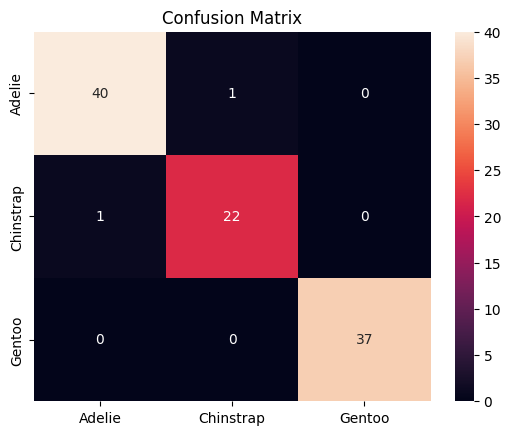

In [76]:
# Confusion Matrix

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot = True, fmt = 'd',
            xticklabels = ['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels = ['Adelie', 'Chinstrap', 'Gentoo']).set(title = 'Confusion Matrix')
plt.show()

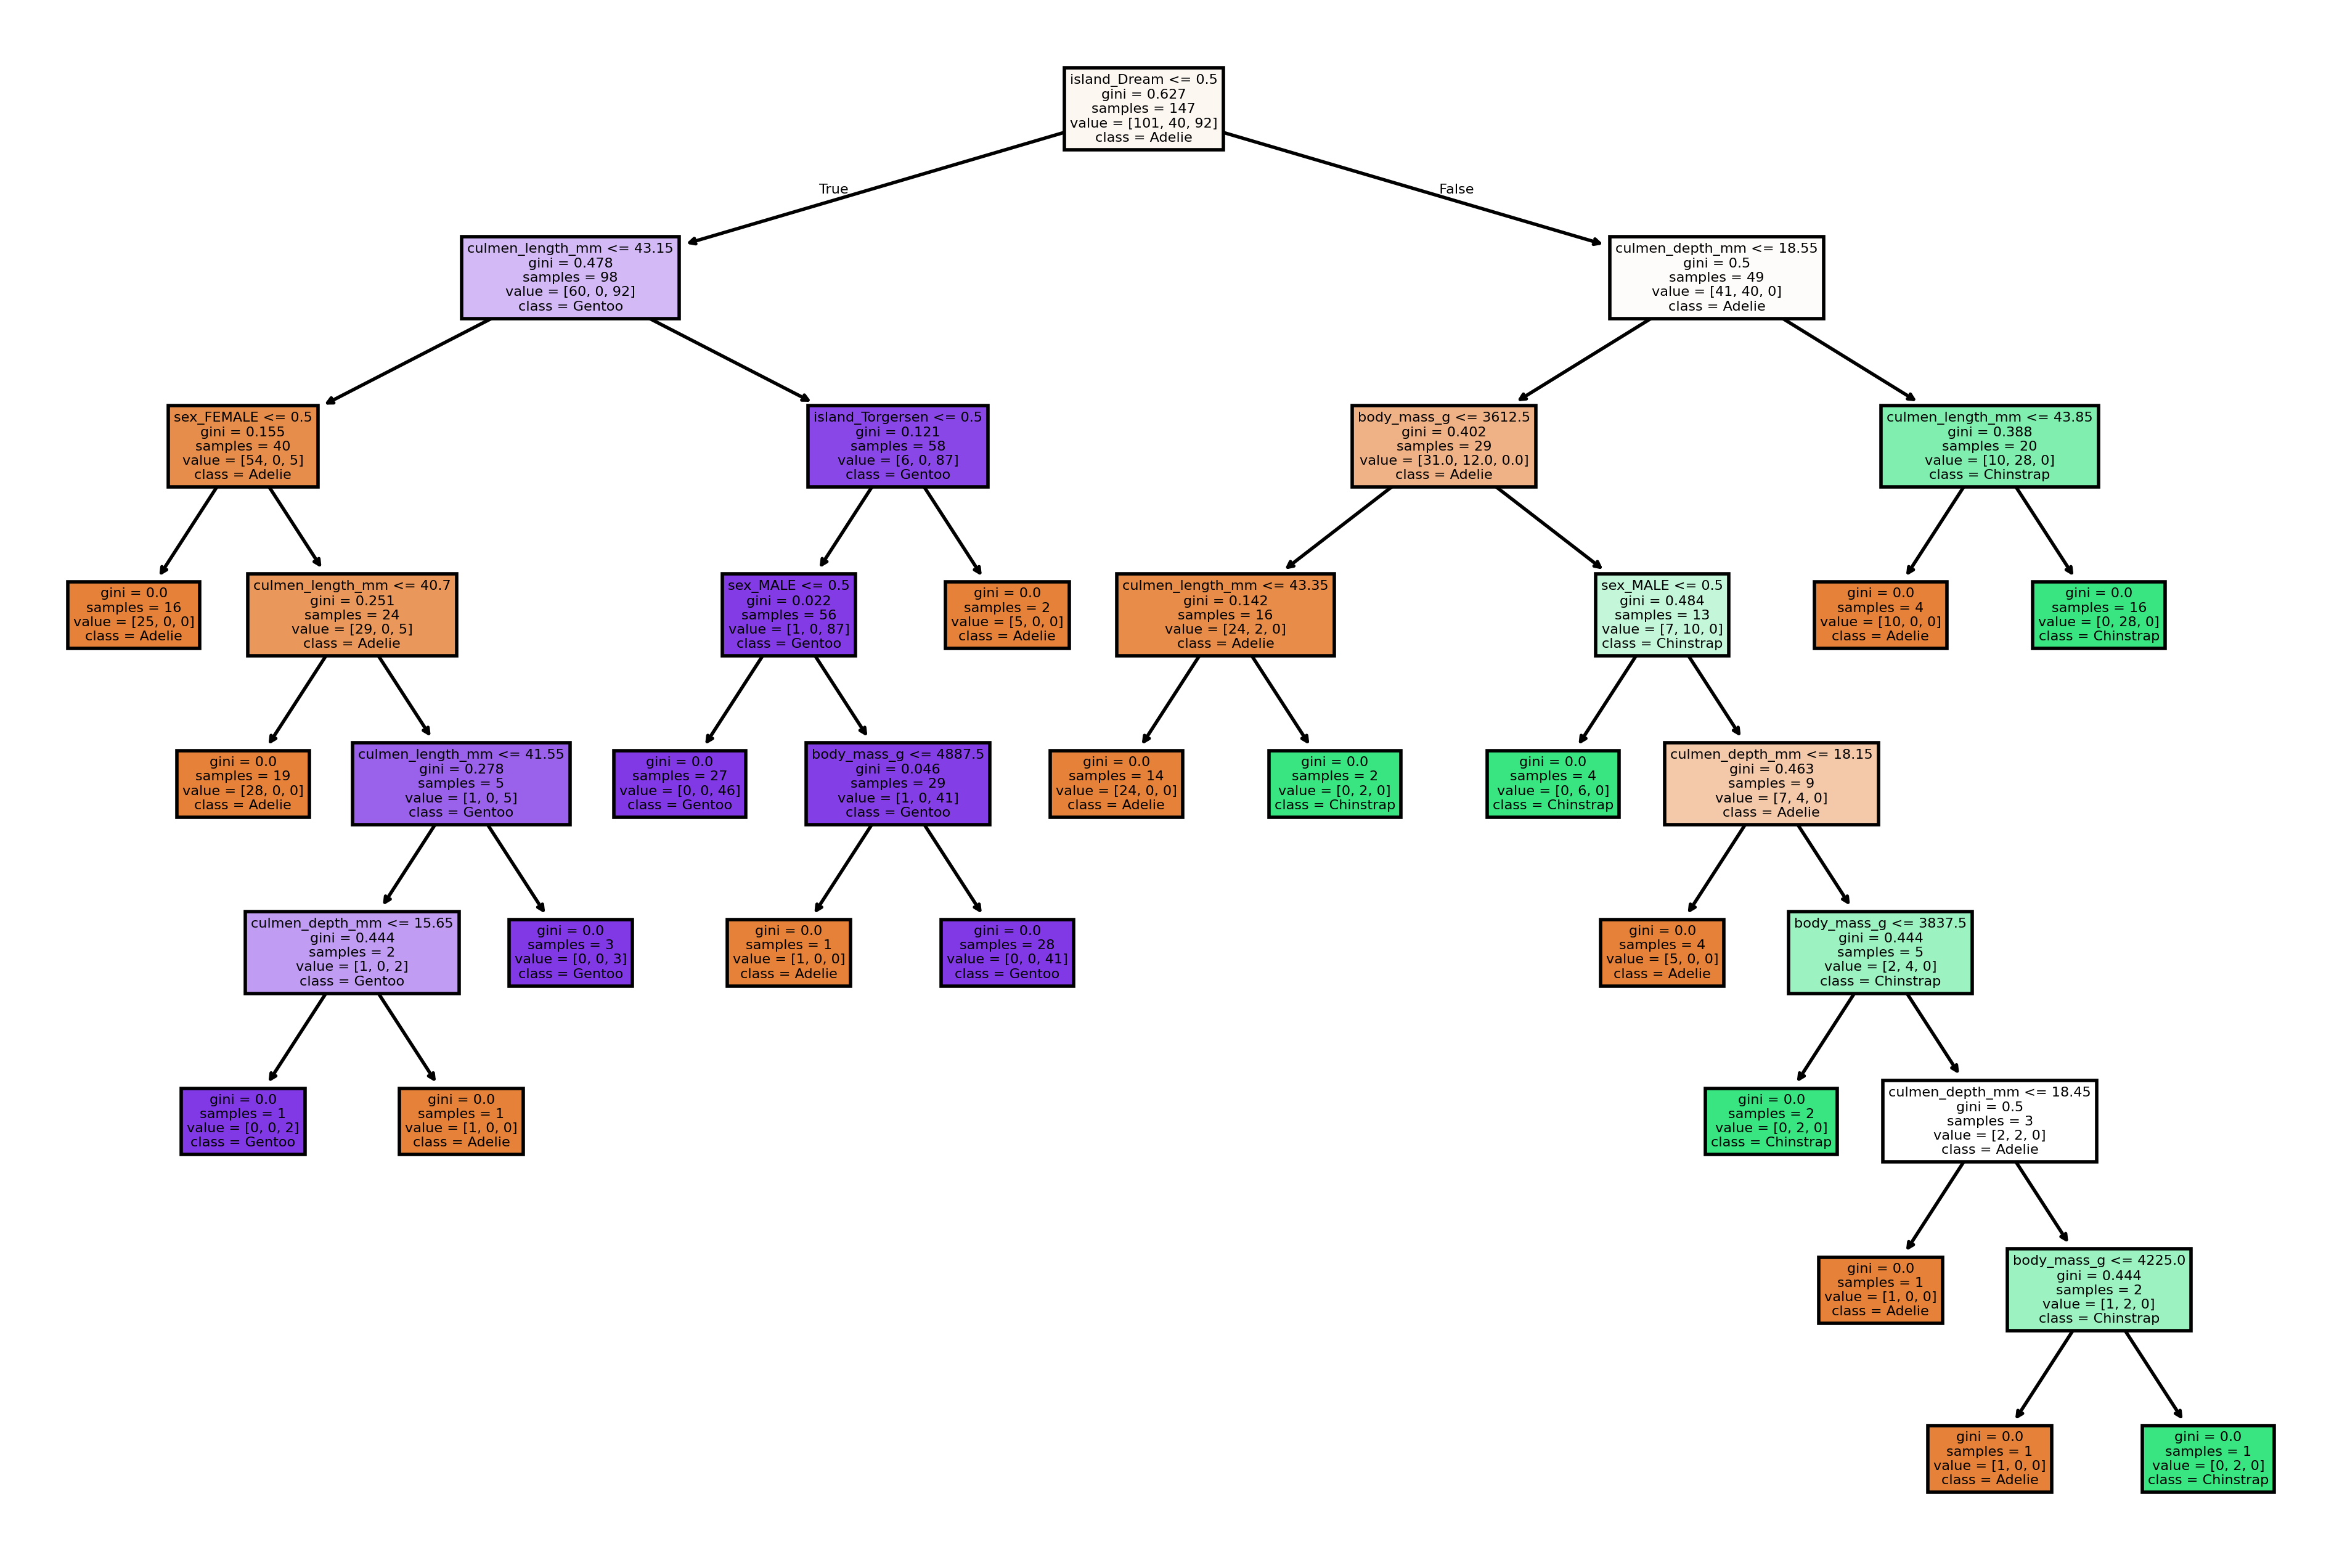

In [77]:
# Tree Visualization (Graph)

from sklearn.tree import plot_tree # Implementation, left (true), right (false)

plt.figure(figsize = (12,8), dpi = 400)
plot_tree(model.estimators_[0], feature_names = X.columns, filled = True, class_names = ['Adelie', 'Chinstrap', 'Gentoo']);